# Library and Dataset Information

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import scale, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report

In [2]:
plt.rcdefaults()

In [3]:
df = pd.read_csv("/content/drive/MyDrive/diabetes dataset/diabetes.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


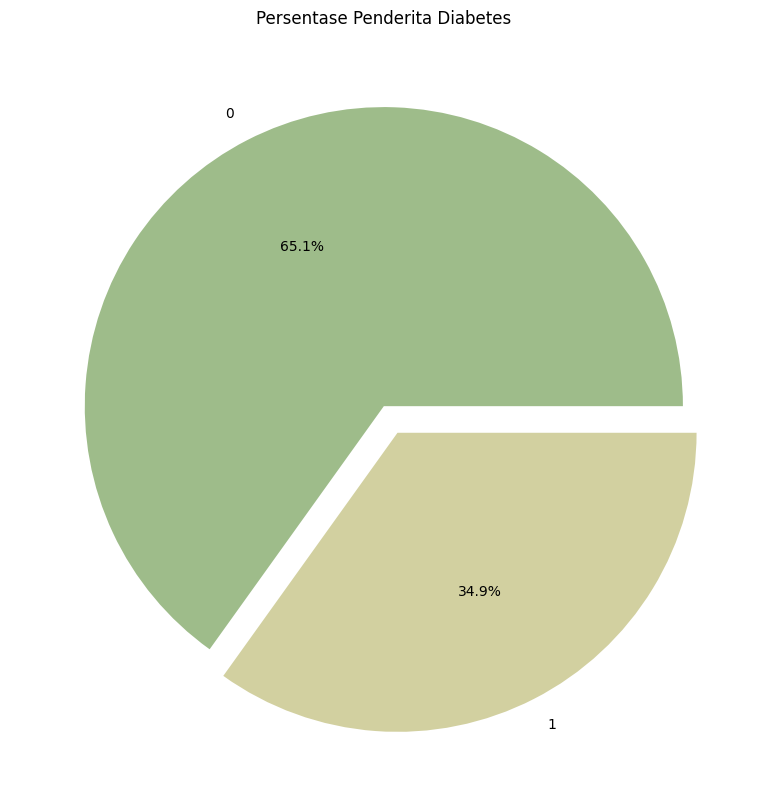

In [6]:
custom_colors = ['#9EBC8A', '#D2D0A0']  # [warna kelas 0, warna kelas 1]

f, ax = plt.subplots(figsize=(18, 8))
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct="%1.1f%%", ax=ax, shadow=False, colors=custom_colors)
ax.set_title('Persentase Penderita Diabetes')
ax.set_ylabel('')

plt.tight_layout()
#plt.savefig("persentase_penderita_diabetes.png", dpi=1000)
plt.show()

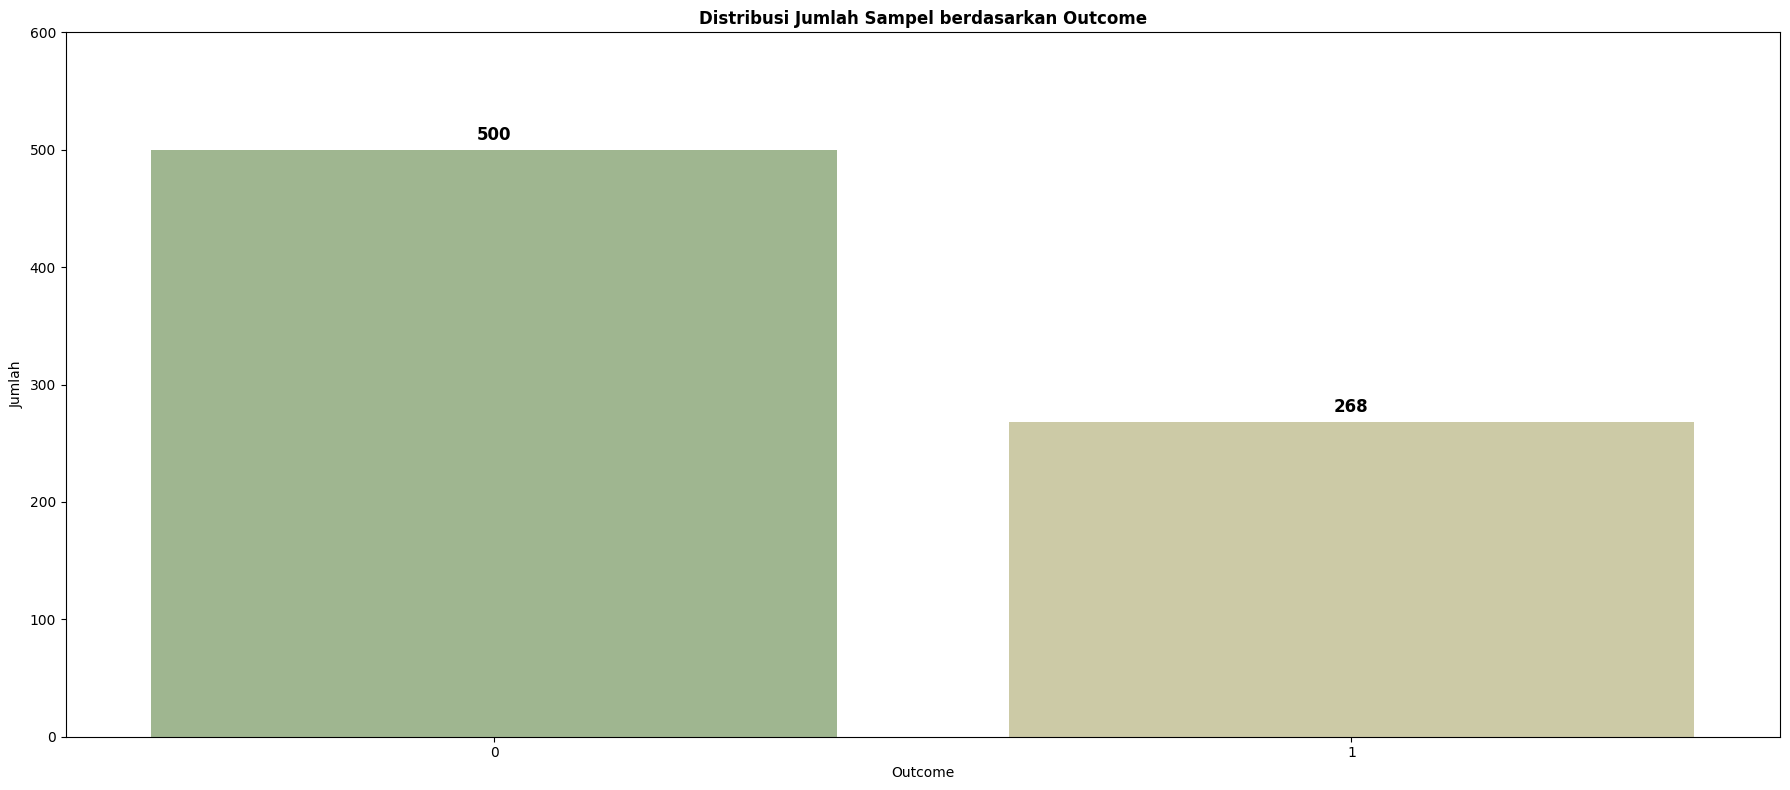

In [7]:
custom_colors = ['#9EBC8A', '#D2D0A0']  # Warna untuk kelas 0 dan 1

# Buat plot
f, ax = plt.subplots(figsize=(18, 8))
sns.countplot(x='Outcome', hue='Outcome', data=df, ax=ax, palette=custom_colors, legend=False)
ax.set_xlabel('Outcome')
ax.set_ylabel('Jumlah')
ax.set_ylim(0, df['Outcome'].value_counts().max() * 1.2)  # beri ruang untuk label
ax.set_title('Distribusi Jumlah Sampel berdasarkan Outcome', fontweight='bold')

# Tambahkan jumlah di atas batang
for p in ax.patches[:2]:  # hanya 2 batang utama (Outcome 0 dan 1)
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
#plt.savefig("distribusi_jumlah_sampel.png", dpi=1000)
plt.show()

# Pre-Processing

missing values

In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


deteksi outlier

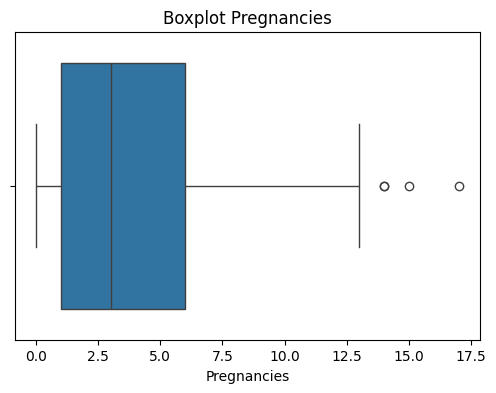

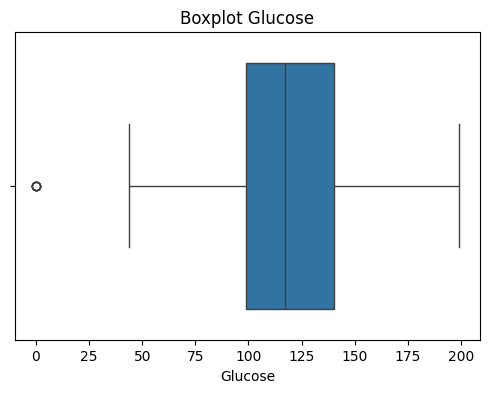

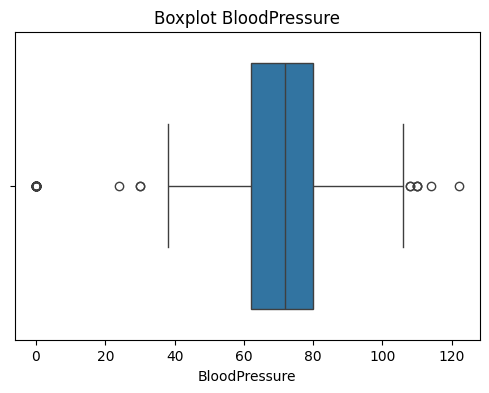

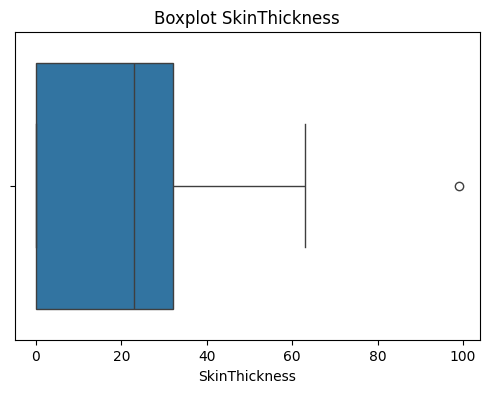

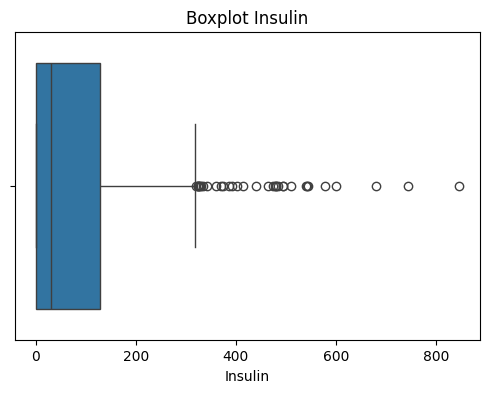

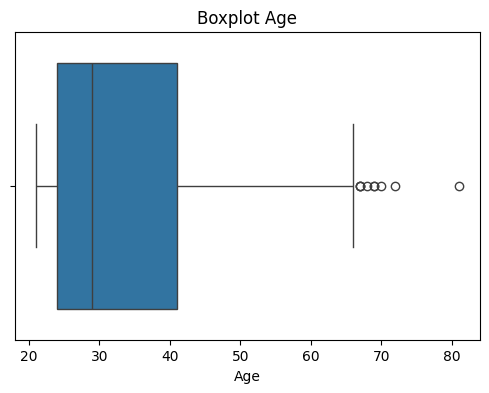

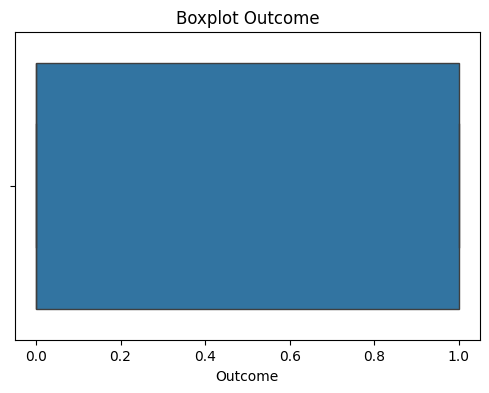

In [9]:
for col in df.select_dtypes(include=['int64']).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_counts = ((df < lower_bound) | (df > upper_bound)).sum()

outlier_table = pd.DataFrame({'Feature': outlier_counts.index, 'Jumlah Outlier': outlier_counts.values})
print(outlier_table)

                    Feature  Jumlah Outlier
0               Pregnancies               4
1                   Glucose               5
2             BloodPressure              45
3             SkinThickness               1
4                   Insulin              34
5                       BMI              19
6  DiabetesPedigreeFunction              29
7                       Age               9
8                   Outcome               0


In [11]:
df_cleaned = df.copy()

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    median = df[col].median()

    # mengganti nilai di luar batas bawah dan atas dengan median
    df_cleaned[col] = np.where(
        (df[col] < lower_bound[col]) | (df[col] > upper_bound[col]),
        median,
        df[col]
    )

outlier_counts_after = ((df_cleaned < lower_bound) | (df_cleaned > upper_bound)).sum()
outlier_table_after = pd.DataFrame({'Feature': outlier_counts_after.index, 'Sisa Outlier': outlier_counts_after.values})

print("\nJumlah Outlier Setelah Penanganan:")
print(outlier_table_after)


Jumlah Outlier Setelah Penanganan:
                    Feature  Sisa Outlier
0               Pregnancies             0
1                   Glucose             0
2             BloodPressure             0
3             SkinThickness             0
4                   Insulin             0
5                       BMI             0
6  DiabetesPedigreeFunction             0
7                       Age             0
8                   Outcome             0


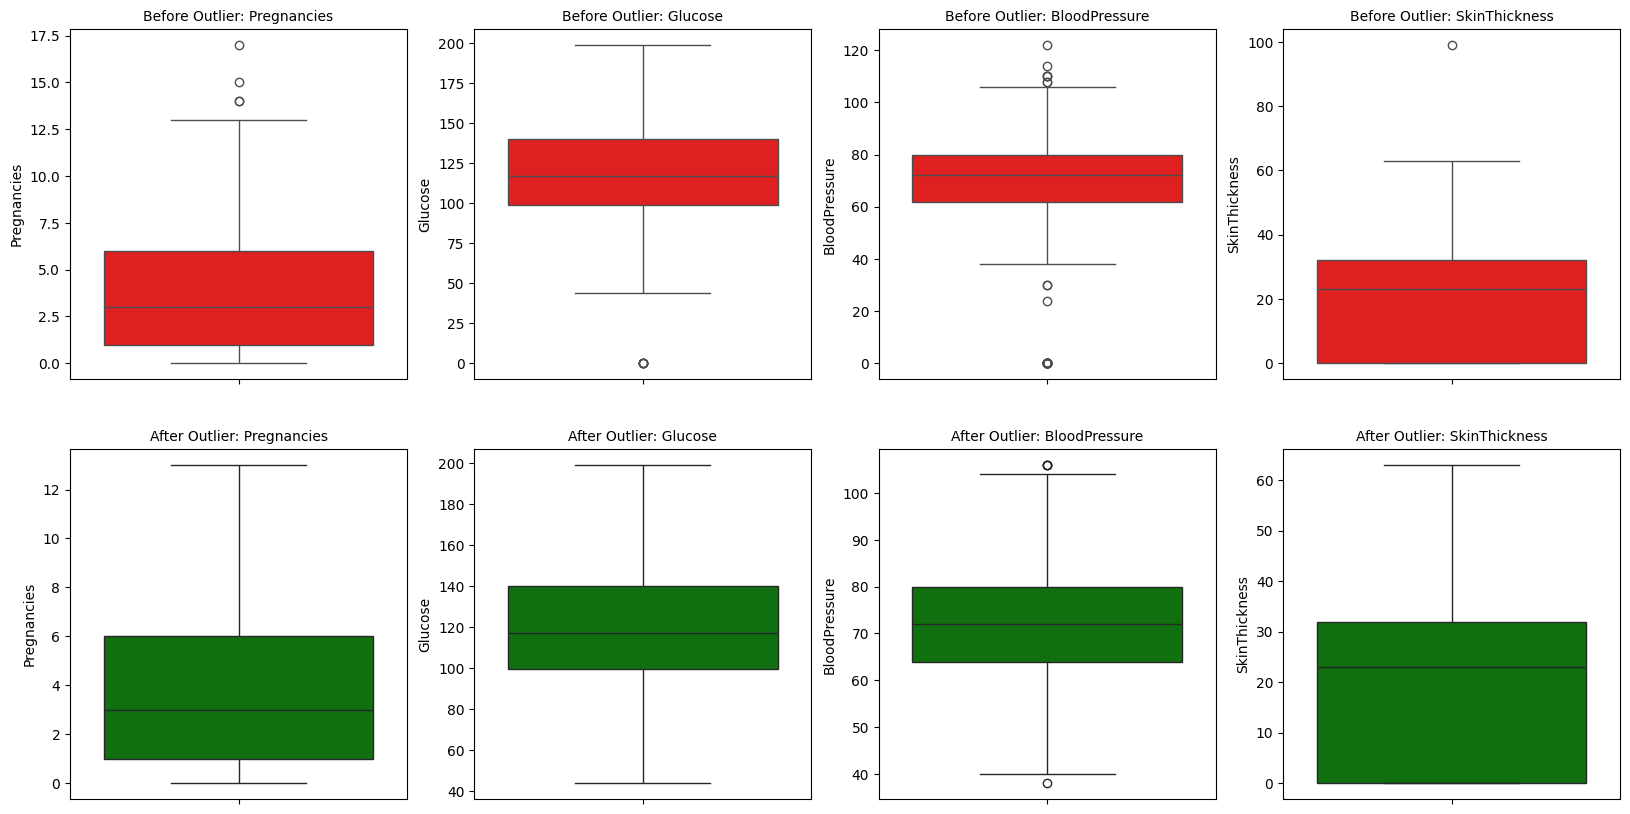

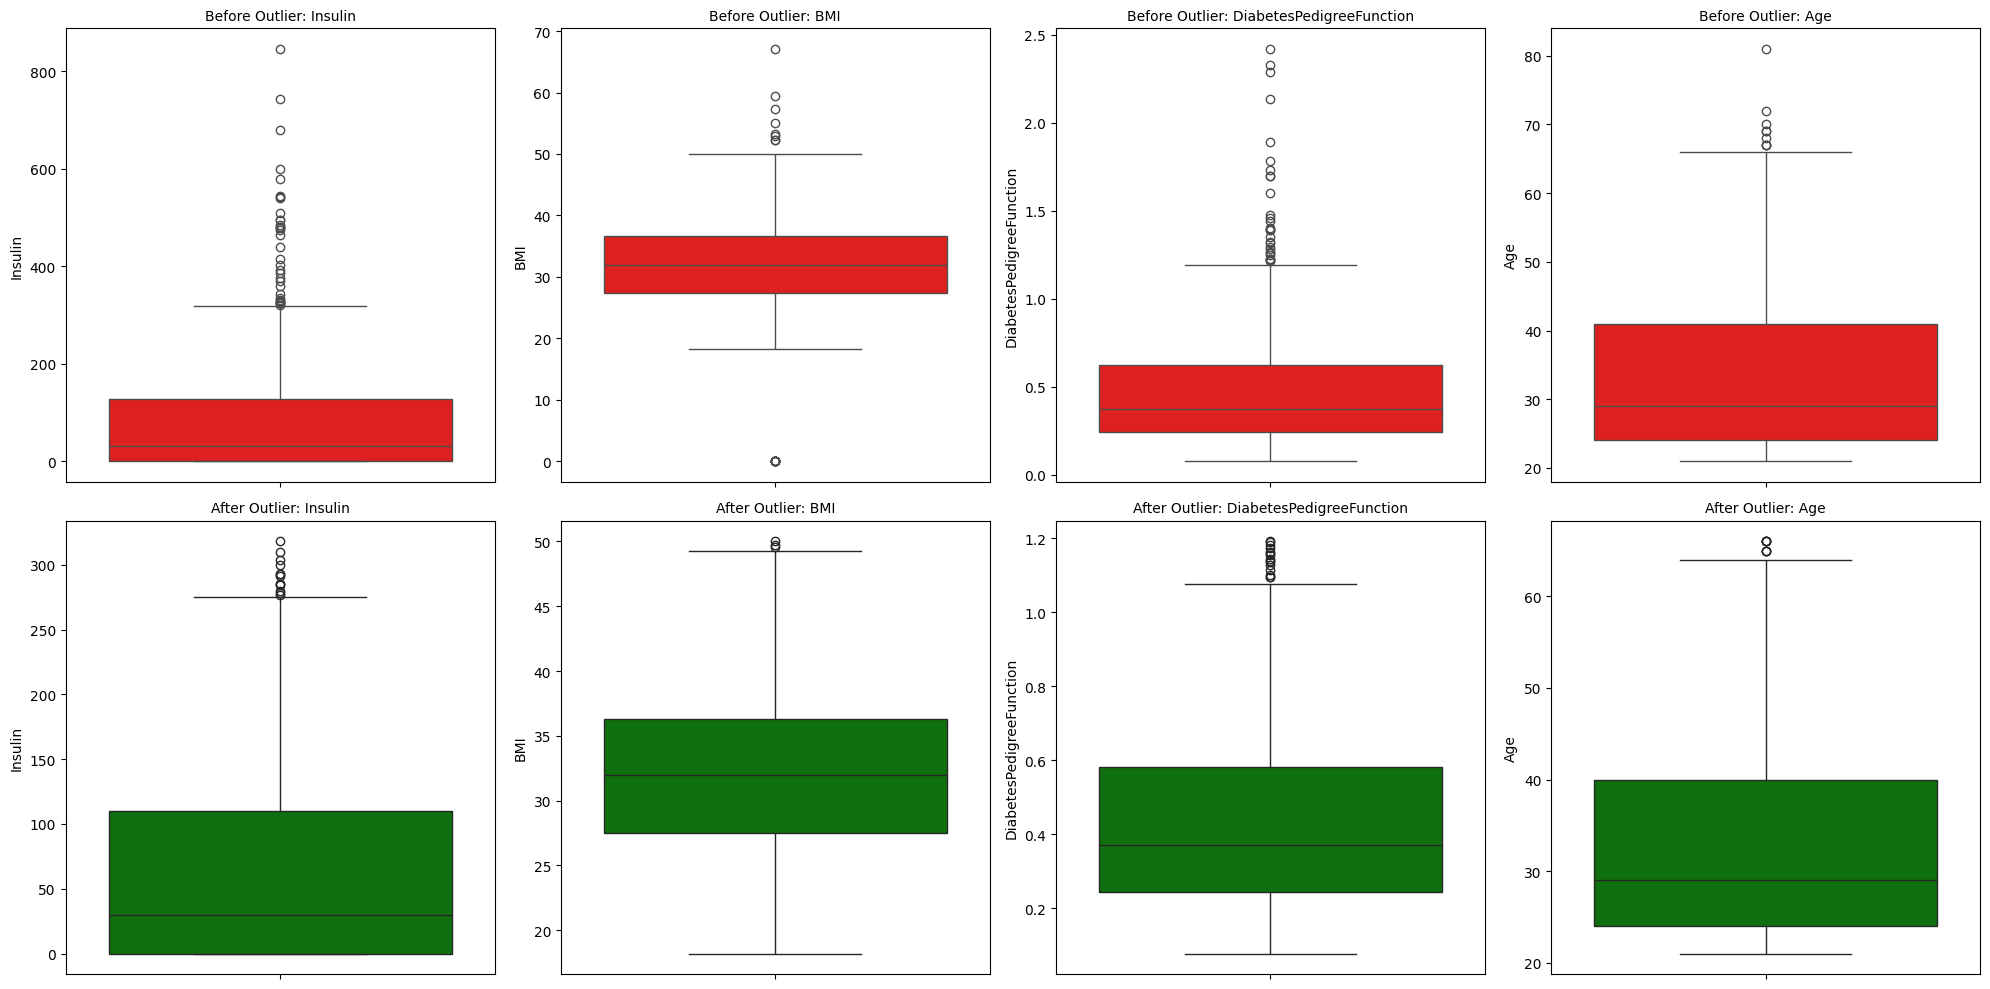

In [12]:
features = ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

for i, col in enumerate(features[:4]):
    sns.boxplot(y=df[col], ax=axes[0, i], color='red')
    axes[0, i].set_title(f"Before Outlier: {col}", fontsize=10)

for i, col in enumerate(features[:4]):
    sns.boxplot(y=df_cleaned[col], ax=axes[1, i], color='green')
    axes[1, i].set_title(f"After Outlier: {col}", fontsize=10)

#untuk fitur sisanya
fig2, axes2 = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

for i, col in enumerate(features[4:]):
    sns.boxplot(y=df[col], ax=axes2[0, i], color='red')
    axes2[0, i].set_title(f"Before Outlier: {col}", fontsize=10)

for i, col in enumerate(features[4:]):
    sns.boxplot(y=df_cleaned[col], ax=axes2[1, i], color='green')
    axes2[1, i].set_title(f"After Outlier: {col}", fontsize=10)

plt.tight_layout()
plt.show()

Feature Engineering

In [13]:
# Feature Enginnering
NewBMI = pd.Series(["Underweight","Normal", "Overweight","Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")

In [14]:
NewBMI

,0
0,Underweight
1,Normal
2,Overweight
3,Obesity 1
4,Obesity 2
5,Obesity 3


In [15]:
df_cleaned['NewBMI'] = NewBMI
df_cleaned.loc[df["BMI"]<18.5, "NewBMI"] = NewBMI[0]
df_cleaned.loc[(df["BMI"]>18.5) & df["BMI"]<=24.9, "NewBMI"] = NewBMI[1]
df_cleaned.loc[(df["BMI"]>24.9) & df["BMI"]<=29.9, "NewBMI"] = NewBMI[2]
df_cleaned.loc[(df["BMI"]>29.9) & df["BMI"]<=34.9, "NewBMI"] = NewBMI[3]
df_cleaned.loc[(df["BMI"]>34.9) & df["BMI"]<=39.9, "NewBMI"] = NewBMI[4]
df_cleaned.loc[df["BMI"]>39.9, "NewBMI"] = NewBMI[5]

In [16]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI
0,6.0,148.0,72.0,35.0,0.0,33.6,0.6270,50.0,1.0,Obesity 2
1,1.0,85.0,66.0,29.0,0.0,26.6,0.3510,31.0,0.0,Obesity 2
2,8.0,183.0,64.0,0.0,0.0,23.3,0.6720,32.0,1.0,Obesity 2
3,1.0,89.0,66.0,23.0,94.0,28.1,0.1670,21.0,0.0,Obesity 2
4,0.0,137.0,40.0,35.0,168.0,43.1,0.3725,33.0,1.0,Obesity 3


In [17]:
# if insulin>=16 & insuline<=166->normal
def set_insuline(row):
    if row["Insulin"]>=16 and row["Insulin"]<=166:
        return "Normal"
    else:
        return "Abnormal"

In [18]:
df_cleaned = df_cleaned.assign(NewInsulinScore=df.apply(set_insuline, axis=1))

In [19]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore
0,6.0,148.0,72.0,35.0,0.0,33.6,0.6270,50.0,1.0,Obesity 2,Abnormal
1,1.0,85.0,66.0,29.0,0.0,26.6,0.3510,31.0,0.0,Obesity 2,Abnormal
2,8.0,183.0,64.0,0.0,0.0,23.3,0.6720,32.0,1.0,Obesity 2,Abnormal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.1670,21.0,0.0,Obesity 2,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,0.3725,33.0,1.0,Obesity 3,Abnormal


In [20]:
# Some intervals were determined according to the glucose variable and these were assigned categorical variables.
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype = "category")
df_cleaned["NewGlucose"] = NewGlucose
df_cleaned.loc[df["Glucose"] <= 70, "NewGlucose"] = NewGlucose[0]
df_cleaned.loc[(df["Glucose"] > 70) & (df["Glucose"] <= 99), "NewGlucose"] = NewGlucose[1]
df_cleaned.loc[(df["Glucose"] > 99) & (df["Glucose"] <= 126), "NewGlucose"] = NewGlucose[2]
df_cleaned.loc[df["Glucose"] > 126 ,"NewGlucose"] = NewGlucose[3]

In [21]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore,NewGlucose
0,6.0,148.0,72.0,35.0,0.0,33.6,0.6270,50.0,1.0,Obesity 2,Abnormal,Secret
1,1.0,85.0,66.0,29.0,0.0,26.6,0.3510,31.0,0.0,Obesity 2,Abnormal,Normal
2,8.0,183.0,64.0,0.0,0.0,23.3,0.6720,32.0,1.0,Obesity 2,Abnormal,Secret
3,1.0,89.0,66.0,23.0,94.0,28.1,0.1670,21.0,0.0,Obesity 2,Normal,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,0.3725,33.0,1.0,Obesity 3,Abnormal,Secret


In [22]:
# One hot encoding
df_cleaned = pd.get_dummies(df_cleaned, columns = ["NewBMI", "NewInsulinScore", "NewGlucose"], drop_first=True).astype(int)

In [23]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6,148,72,35,0,33,0,50,1,0,1,0,0,0,0,0,0,0,1
1,1,85,66,29,0,26,0,31,0,0,1,0,0,0,0,0,1,0,0
2,8,183,64,0,0,23,0,32,1,0,1,0,0,0,0,0,0,0,1
3,1,89,66,23,94,28,0,21,0,0,1,0,0,0,1,0,1,0,0
4,0,137,40,35,168,43,0,33,1,0,0,1,0,0,0,0,0,0,1


In [24]:
df_cleaned.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret'],
      dtype='object')

In [25]:
categorical_df = df_cleaned[['NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Low',
       'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']]

In [26]:
categorical_df.head()

,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Low,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,0,1,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,1
3,0,1,0,0,0,1,0,1,0,0
4,0,0,1,0,0,0,0,0,0,1


# Normalisasi dan Pemisahan Data

In [27]:
X = df_cleaned.drop(['Outcome'], axis=1)
y = df_cleaned['Outcome']

In [28]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=0)

# Model ML

In [29]:
rf_model = RandomForestClassifier(criterion = 'entropy', max_depth = None , max_features = 0.75, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 250, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_features=0.75, n_estimators=250)

In [30]:
y_pred = rf_model.predict(X_test)

In [31]:
print(accuracy_score(y_train, rf_model.predict(X_train)))
rand_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(accuracy_score(y_test, rf_model.predict(X_test)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1.0
0.8311688311688312
[[94 13]
 [13 34]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       107
           1       0.72      0.72      0.72        47

    accuracy                           0.83       154
   macro avg       0.80      0.80      0.80       154
weighted avg       0.83      0.83      0.83       154



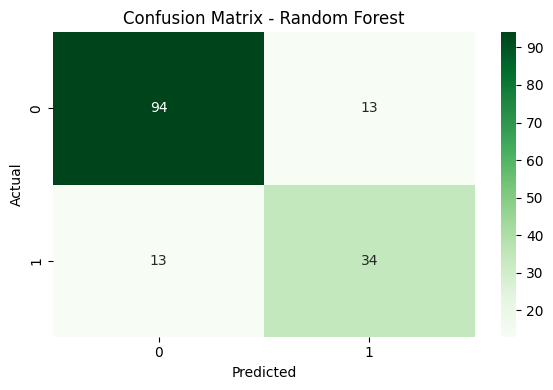

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=1000)
plt.show()

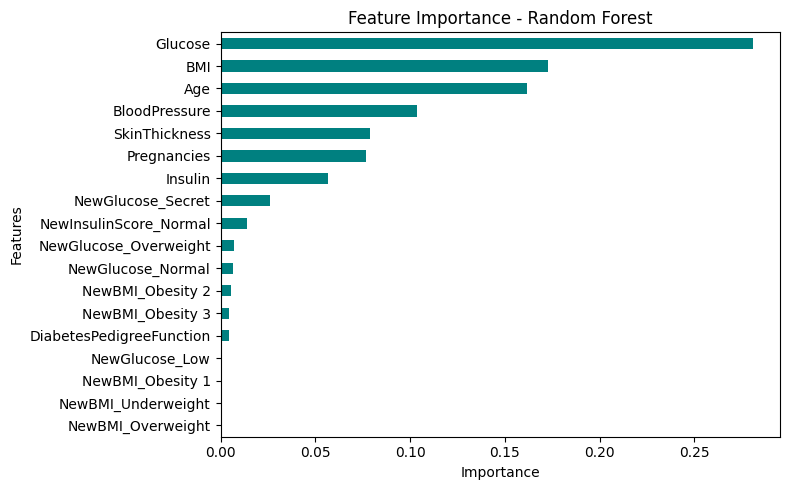

In [33]:
# Ambil dan urutkan pentingnya fitur
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Visualisasi horizontal
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=1000)
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Akurasi CV:", cv_scores)
print("Rata-rata Akurasi CV:", cv_scores.mean())

Akurasi CV: [0.75974026 0.70779221 0.78571429 0.82352941 0.75163399]
Rata-rata Akurasi CV: 0.7656820303879128


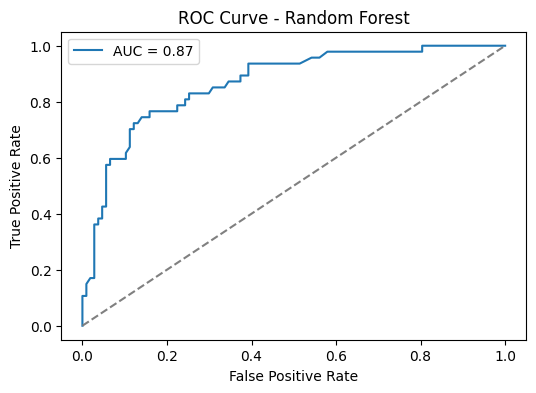

In [35]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.savefig("roc_curve.png", dpi=1000)
plt.show()

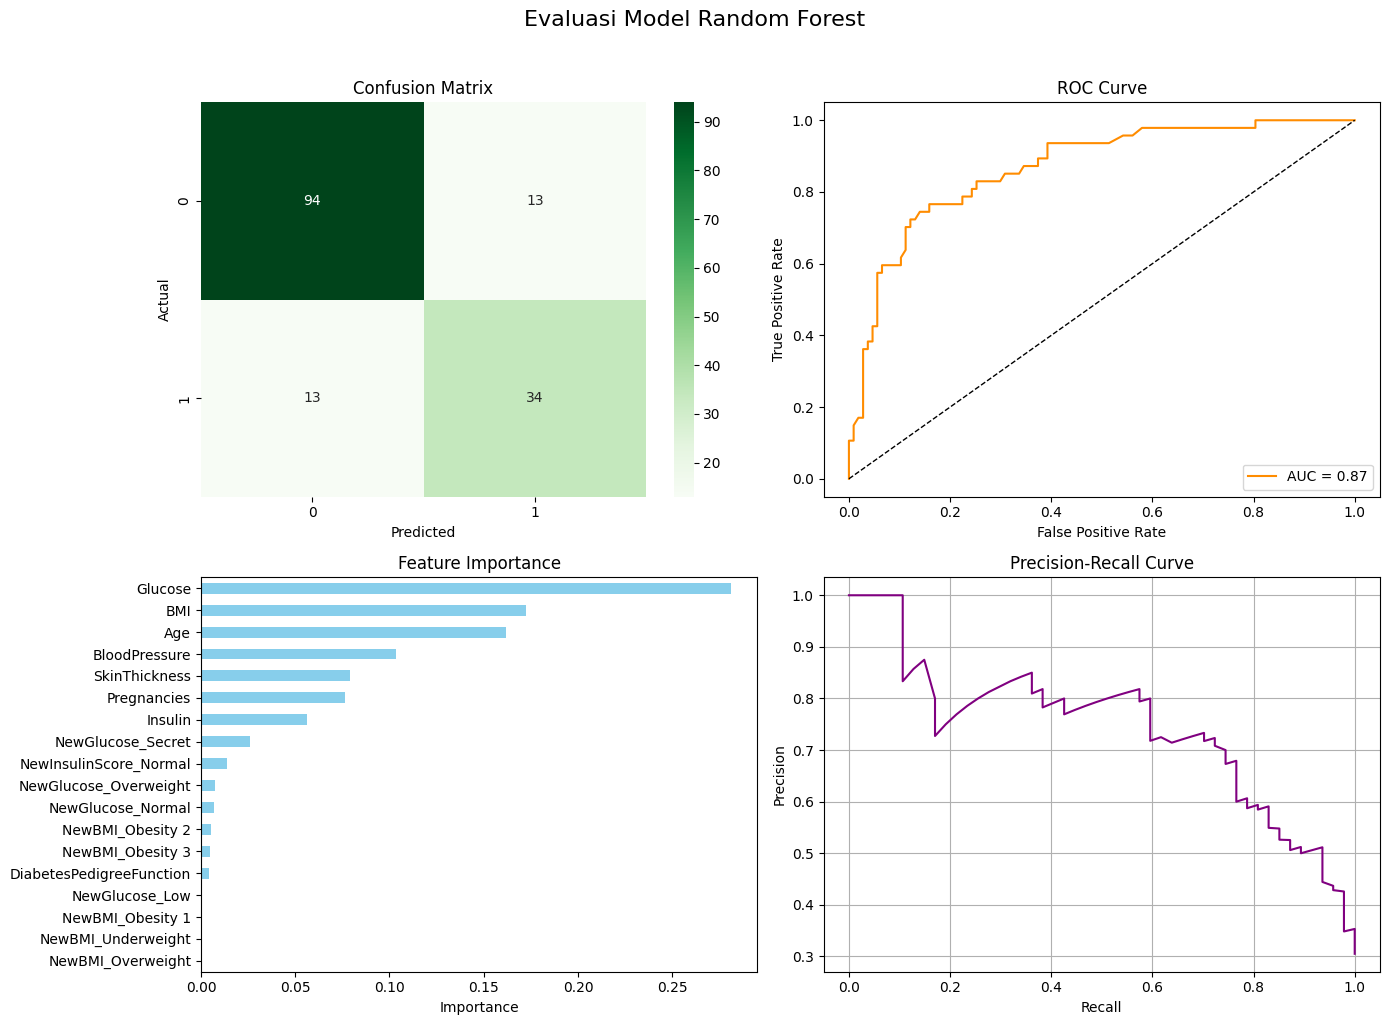

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import pandas as pd

# === 1. Hitung hasil evaluasi ===
# Prediksi probabilitas untuk ROC dan Precision-Recall
y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Feature importance
importances = rf_model.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

# === 2. Layout plotting ===
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

# — Confusion Matrix —
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axs[0, 0])
axs[0, 0].set_title('Confusion Matrix')
axs[0, 0].set_xlabel('Predicted')
axs[0, 0].set_ylabel('Actual')

# — ROC Curve —
axs[0, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange')
axs[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axs[0, 1].set_title('ROC Curve')
axs[0, 1].set_xlabel('False Positive Rate')
axs[0, 1].set_ylabel('True Positive Rate')
axs[0, 1].legend(loc='lower right')

# — Feature Importance —
feat_imp.plot(kind='barh', ax=axs[1, 0], color='skyblue')
axs[1, 0].set_title('Feature Importance')
axs[1, 0].set_xlabel('Importance')

# — Precision-Recall Curve —
axs[1, 1].plot(recall, precision, color='purple')
axs[1, 1].set_title('Precision-Recall Curve')
axs[1, 1].set_xlabel('Recall')
axs[1, 1].set_ylabel('Precision')
axs[1, 1].grid()

# === Save as HD image (optional) ===
plt.suptitle("Evaluasi Model Random Forest", fontsize=16, y=1.02)
plt.tight_layout()
#plt.savefig("rf_model_evaluation_summary.png", dpi=1000)
plt.show()

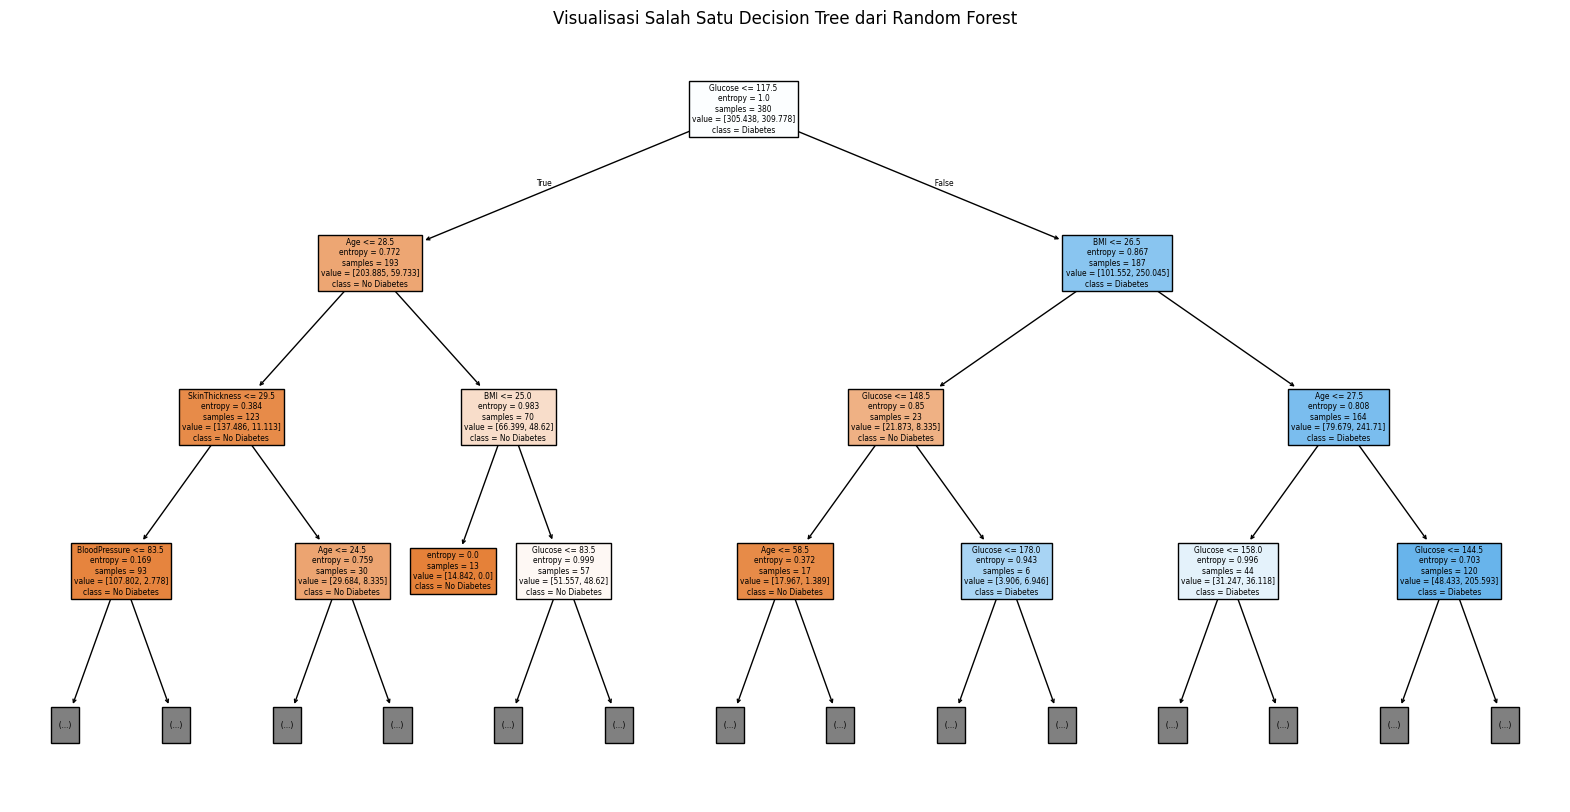

In [37]:
from sklearn.tree import plot_tree

# Ambil salah satu tree dari Random Forest
plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], feature_names=X.columns, class_names=["No Diabetes", "Diabetes"], filled=True, max_depth=3)
plt.title("Visualisasi Salah Satu Decision Tree dari Random Forest")
plt.show()